# Models analyses

1. Import models

In [23]:
import pickle
from pathlib import Path

model_paths = {
    "RF no-odds": Path("../models/rf_no_odds_model.pkl"),
    "RF with-odds": Path("../models/rf_with_odds_model.pkl"),
    "XGB no-odds": Path("../models/xgb_no_odds_model.pkl"),
    "XGB with-odds": Path("../models/xgb_with_odds_model.pkl"),
}

models = {}
for name, path in model_paths.items():
    with open(path, "rb") as f:
        models[name] = pickle.load(f)


2. Import testing set

In [24]:
import numpy as np, pandas as pd
from IPython.display import display

TESTING_PATH = "../data/testing/tennis_testing.xlsx"

test_set = pd.read_excel(TESTING_PATH)

target = "y"
y_test = test_set[target]

print(f"Loaded prepared test set with {len(test_set)} rows")


Loaded prepared test set with 16482 rows


### Baselines

In [42]:
def baseline_accuracy(name, prediction, valid_mask, y_test):
    """Accuracy of a prediction rule, computed only on matches where it applies."""
    accuracy = (prediction[valid_mask] == y_test[valid_mask]).mean()
    coverage = valid_mask.mean()
    print(f"{name}: {accuracy:.2%}  (coverage: {coverage:.1%})")


# Majority class: whichever class (0 or 1) is more common in the test set.
maj_acc = y_test.value_counts().max() / y_test.value_counts().sum()
print(f"Majority class: {maj_acc:.2%}")

baseline_accuracy("Ranking", test_set["Rank_Log_Ratio"] > 0, test_set["Rank_Log_Ratio"].notna(), y_test)
baseline_accuracy("Points", test_set["Points_Log_Ratio"] > 0, test_set["Points_Log_Ratio"].notna(), y_test)

valid_odds = test_set["Odds_1"].notna() & test_set["Odds_2"].notna() & (test_set["Odds_1"] != test_set["Odds_2"])
baseline_accuracy("Market (odds)", test_set["Odds_1"] < test_set["Odds_2"], valid_odds, y_test)


Majority class: 50.16%
Ranking: 63.65%  (coverage: 99.8%)
Points: 63.38%  (coverage: 99.8%)
Market (odds): 68.51%  (coverage: 97.1%)


## Model Evaluation

In [43]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    log_loss,
    roc_auc_score,
    brier_score_loss,
    f1_score
)

def get_model_data(model, test_set):
    model_features = list(model.feature_names_in_)
    X = test_set[model_features]
    y = test_set["y"]
    proba = model.predict_proba(X)[:, 1]
    pred = (proba >= 0.5).astype(int)
    return model_features, X, y, proba, pred

def evaluate_model(name, model, test_set):
    model_features, X, y, proba, pred = get_model_data(model, test_set)

    print(f"{name}")
    print(" Accuracy:", f"{accuracy_score(y, pred):.2%}")
    print(" F1-Score:", f"{f1_score(y, pred):.4f}")
    print(" ROC AUC:", f"{roc_auc_score(y, proba):.4f}")
    print(" Log loss:", f"{log_loss(y, proba):.4f}")
    print(" Brier Score:", f"{brier_score_loss(y, proba):.4f}")
    print(" Confusion matrix:")
    print(" " + str(confusion_matrix(y, pred)))
    print()

    return {
        "name": name,
        "features": model_features,
        "X": X,
        "y": y,
        "proba": proba,
        "pred": pred,
    }
    
results = {name: evaluate_model(name, model, test_set) for name, model in models.items()}

RF no-odds
 Accuracy: 65.06%
 F1-Score: 0.6477
 ROC AUC: 0.7143
 Log loss: 0.6169
 Brier Score: 0.2146
 Confusion matrix:
 [[5429 2839]
 [2920 5294]]

RF with-odds
 Accuracy: 67.33%
 F1-Score: 0.6699
 ROC AUC: 0.7397
 Log loss: 0.5980
 Brier Score: 0.2063
 Confusion matrix:
 [[5632 2636]
 [2749 5465]]

XGB no-odds
 Accuracy: 65.17%
 F1-Score: 0.6476
 ROC AUC: 0.7168
 Log loss: 0.6156
 Brier Score: 0.2141
 Confusion matrix:
 [[5469 2799]
 [2941 5273]]

XGB with-odds
 Accuracy: 68.03%
 F1-Score: 0.6801
 ROC AUC: 0.7471
 Log loss: 0.5917
 Brier Score: 0.2036
 Confusion matrix:
 [[5609 2659]
 [2611 5603]]



## Feature Usage

In [27]:
def source_feature_name(transformed_name, model_features):
    # Map transformed one-hot and missing-indicator names back to source columns.
    if transformed_name.startswith("num__missingindicator_"):
        return transformed_name.removeprefix("num__missingindicator_")
    if transformed_name.startswith("num__"):
        return transformed_name.removeprefix("num__")
    if transformed_name.startswith("cat__"):
        encoded = transformed_name.removeprefix("cat__")
    elif transformed_name.startswith("high_cardinality__"):
        encoded = transformed_name.removeprefix("high_cardinality__")
    else:
        return transformed_name

    for feature in model_features:
        if encoded.startswith(f"{feature}_"):
            return feature
    return encoded


def feature_usage(name, model, top_n=15):
    model_features = list(model.feature_names_in_)
    transformed_names = model[:-1].get_feature_names_out()
    estimator = model.named_steps["model"]

    if hasattr(estimator, "feature_importances_"):
        values = estimator.feature_importances_
        column = "Importance"
    else:
        values = np.abs(estimator.coef_[0])
        column = "Abs_Coefficient"

    usage = pd.DataFrame({"Feature": transformed_names, column: values})
    usage["Source_Feature"] = usage["Feature"].map(
        lambda feature: source_feature_name(feature, model_features)
    )

    usage_by_source = (
        usage.groupby("Source_Feature", as_index=False)[column]
        .sum()
        .sort_values(column, ascending=False)
    )

    print(f"{name} feature usage")
    display(usage_by_source.head(top_n))

for name, model in models.items():
    feature_usage(name, model)


RF no-odds feature usage


,Source_Feature,Importance
13,Surface_Elo_Diff,0.252861
8,Rank_Log_Ratio,0.215253
7,Points_Log_Ratio,0.194568
2,Dominance_Form_Diff,0.178513
9,Recent_Surface_Form_Diff,0.054570
3,Fatigue_Diff,0.021692
4,H2H_Surface_Diff,0.016429
0,Age_Diff,0.015474
14,Tournament,0.014373
11,Series,0.012347


RF with-odds feature usage


,Source_Feature,Importance
7,Odds_Log_Ratio,0.350263
14,Surface_Elo_Diff,0.188968
8,Points_Log_Ratio,0.150230
9,Rank_Log_Ratio,0.117790
2,Dominance_Form_Diff,0.099561
10,Recent_Surface_Form_Diff,0.035037
3,Fatigue_Diff,0.013043
0,Age_Diff,0.009754
4,H2H_Surface_Diff,0.008368
12,Series,0.008321


XGB no-odds feature usage


,Source_Feature,Importance
14,Tournament,0.278400
13,Surface_Elo_Diff,0.216696
10,Round,0.084053
8,Rank_Log_Ratio,0.082862
11,Series,0.079568
7,Points_Log_Ratio,0.078227
2,Dominance_Form_Diff,0.034757
12,Surface,0.031865
0,Age_Diff,0.022678
6,Home_Advantage,0.022151


XGB with-odds feature usage


,Source_Feature,Importance
14,Surface_Elo_Diff,0.396055
7,Odds_Log_Ratio,0.324387
9,Rank_Log_Ratio,0.180978
8,Points_Log_Ratio,0.070985
2,Dominance_Form_Diff,0.027594
0,Age_Diff,0.000000
1,Court,0.000000
3,Fatigue_Diff,0.000000
4,H2H_Surface_Diff,0.000000
5,Hand_Advantage,0.000000


### Feature distribution

In [28]:
for name, res in results.items():
    comparison_df = pd.DataFrame({
        "Correct": res["pred"] == res["y"],
        "Elo_Diff": test_set["Elo_Diff"],
        "Odds_Diff": test_set["Odds_Diff"]
    })
    
    print(f"\n--- {name}: Feature Distribution (Correct vs Wrong) ---")
    display(comparison_df.groupby("Correct")[["Elo_Diff", "Odds_Diff"]].describe())


--- RF no-odds: Feature Distribution (Correct vs Wrong) ---


Elo_Diff                                                          \
           count      mean         std         min         25%       50%   
Correct                                                                    
False     5759.0  1.830439  158.854203 -762.374069  -99.809522  2.066068   
True     10723.0  0.955198  219.256582 -786.147418 -150.245053  2.288043   

                                Odds_Diff                                   \
                75%         max     count      mean       std    min   25%   
Correct                                                                      
False    104.266137  719.930744    5726.0 -0.022499  1.958614 -27.99 -0.97   
True     151.461857  859.132251   10685.0  0.026493  4.982442 -66.00 -1.84   

                             
         50%     75%    max  
Correct                      
False    0.0  0.8475  21.99  
True     0.0  1.6000  66.00


--- RF with-odds: Feature Distribution (Correct vs Wrong) ---


Elo_Diff                                                          \
           count      mean         std         min         25%       50%   
Correct                                                                    
False     5385.0  1.757182  162.460599 -762.374069 -102.918079  0.902567   
True     11097.0  1.020245  216.197738 -786.147418 -145.736020  2.891746   

                                Odds_Diff                                   \
                75%         max     count      mean       std    min   25%   
Correct                                                                      
False    109.134363  719.930744    5353.0 -0.019780  1.991278 -27.99 -0.97   
True     147.765203  859.132251   11058.0  0.023524  4.904533 -66.00 -1.60   

                           
         50%   75%    max  
Correct                    
False    0.0  0.87  21.99  
True     0.0  1.60  66.00


--- XGB no-odds: Feature Distribution (Correct vs Wrong) ---


Elo_Diff                                                          \
           count      mean         std         min         25%       50%   
Correct                                                                    
False     5740.0  2.013874  159.008983 -762.374069  -99.331328  2.218028   
True     10742.0  0.858727  219.104002 -786.147418 -150.596903  2.204251   

                                Odds_Diff                                   \
                75%         max     count      mean       std    min   25%   
Correct                                                                      
False    104.956211  719.930744    5709.0 -0.020110  1.964496 -27.99 -0.97   
True     151.354308  859.132251   10702.0  0.025141  4.977871 -66.00 -1.84   

                           
         50%   75%    max  
Correct                    
False    0.0  0.87  21.99  
True     0.0  1.60  66.00


--- XGB with-odds: Feature Distribution (Correct vs Wrong) ---


Elo_Diff                                                          \
           count      mean         std         min         25%       50%   
Correct                                                                    
False     5270.0  1.377621  163.166021 -762.374069 -103.420500  1.305443   
True     11212.0  1.206210  215.464487 -786.147418 -144.910063  2.734672   

                                Odds_Diff                                    \
                75%         max     count      mean       std     min   25%   
Correct                                                                       
False    106.945355  719.930744    5238.0 -0.014363  2.203771 -33.029 -0.97   
True     147.744556  859.132251   11173.0  0.020539  4.840455 -66.000 -1.60   

                            
         50%   75%     max  
Correct                     
False    0.0  0.97  28.033  
True     0.0  1.60  66.000

<Figure size 600x400 with 0 Axes>

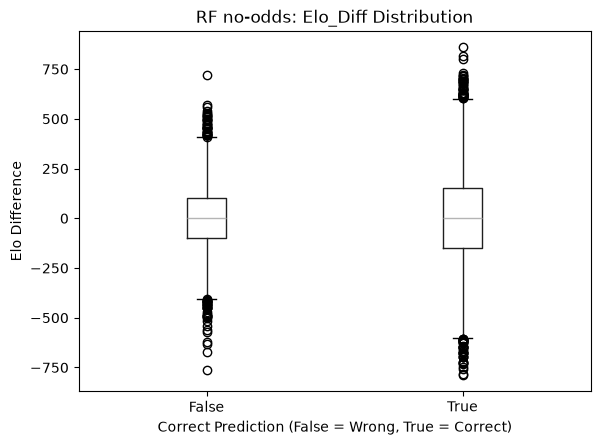

<Figure size 600x400 with 0 Axes>

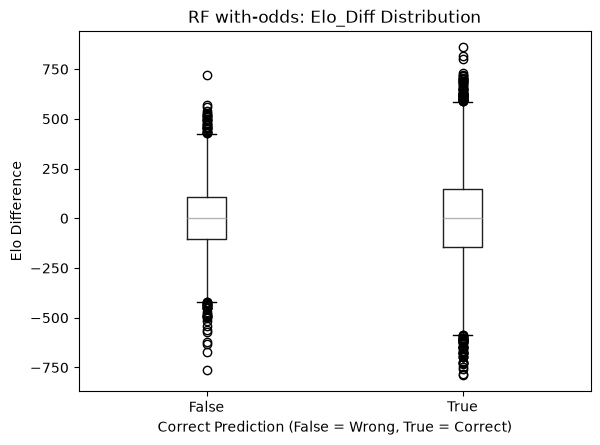

<Figure size 600x400 with 0 Axes>

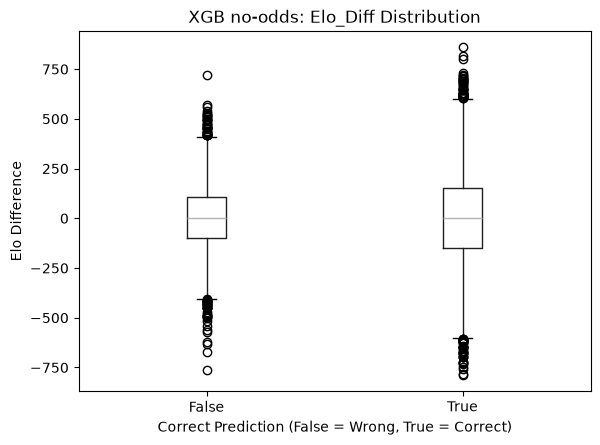

<Figure size 600x400 with 0 Axes>

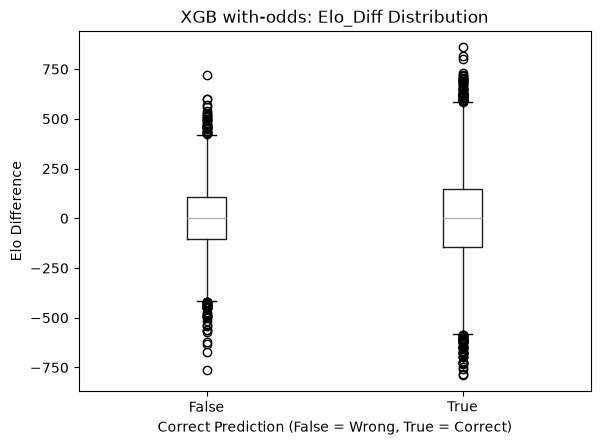

In [29]:
import matplotlib.pyplot as plt

for name, res in results.items():
    comp_df = pd.DataFrame({
        "Correct": res["pred"] == res["y"],
        "Elo_Diff": test_set["Elo_Diff"]
    })
    
    plt.figure(figsize=(6, 4))
    comp_df.boxplot(column="Elo_Diff", by="Correct", grid=False)
    plt.title(f"{name}: Elo_Diff Distribution")
    plt.suptitle("") # Rimuove il sottotitolo automatico di pandas
    plt.xlabel("Correct Prediction (False = Wrong, True = Correct)")
    plt.ylabel("Elo Difference")
    plt.show()

## Most Confident Wrong Matches

In [30]:
def show_most_wrong(name, results, test_set, top_n=10):
    """Show the model's most confident WRONG predictions — useful to spot where it fails."""
    predicted_player_1 = results["pred"] == 1

    wrong = pd.DataFrame({
        "Actual_Winner": np.where(results["y"] == 1, test_set["Player_1"], test_set["Player_2"]),
        "Predicted_Winner": np.where(predicted_player_1, test_set["Player_1"], test_set["Player_2"]),
        "Predicted_Loser": np.where(predicted_player_1, test_set["Player_2"], test_set["Player_1"]),
        "Elo_Diff": test_set["Elo_Diff"],
        "Odds_Diff": test_set["Odds_Diff"],
        # Confidence = probability assigned to whichever player the model predicted
        "Confidence": np.where(predicted_player_1, results["proba"], 1 - results["proba"]),
        "Date": test_set["Date"],
    }, index=test_set.index)

    wrong = wrong[results["y"] != results["pred"]]
    wrong = wrong.sort_values("Confidence", ascending=False).head(top_n)

    print(f"{name}: most confident wrong matches")
    display(wrong)


pd.set_option("display.max_columns", None)

for name, model in models.items():
    show_most_wrong(name, results[name], test_set)

RF no-odds: most confident wrong matches


,Actual_Winner,Predicted_Winner,Predicted_Loser,Elo_Diff,Odds_Diff,Confidence,Date
15950,cerundolo j.m.,sinner j.,cerundolo j.m.,719.930744,-24.99,0.917222,2026-05-28
6082,holt b.,fritz t.,holt b.,-439.408260,11.96,0.900629,2022-08-29
7950,seyboth wild t.,medvedev d.,seyboth wild t.,-622.909796,9.95,0.896990,2023-05-30
11542,van de zandschulp b.,alcaraz c.,van de zandschulp b.,494.659753,-27.99,0.895961,2024-08-30
6084,galan d.e.,tsitsipas s.,galan d.e.,391.998462,-11.96,0.894335,2022-08-30
14405,griekspoor t.,sinner j.,griekspoor t.,-488.763408,17.98,0.894193,2025-10-05
1208,altmaier d.,berrettini m.,altmaier d.,-285.630653,3.84,0.890168,2020-10-03
9553,cazaux a.,rune h.,cazaux a.,-450.246228,4.36,0.885017,2024-01-18
12200,passaro f.,dimitrov g.,passaro f.,470.942878,-9.95,0.884751,2025-01-13
4584,gojowczyk p.,zverev a.,gojowczyk p.,461.301125,-8.94,0.882994,2022-02-24


RF with-odds: most confident wrong matches


,Actual_Winner,Predicted_Winner,Predicted_Loser,Elo_Diff,Odds_Diff,Confidence,Date
15950,cerundolo j.m.,sinner j.,cerundolo j.m.,719.930744,-24.99,0.952892,2026-05-28
6084,galan d.e.,tsitsipas s.,galan d.e.,391.998462,-11.96,0.932474,2022-08-30
11542,van de zandschulp b.,alcaraz c.,van de zandschulp b.,494.659753,-27.99,0.931770,2024-08-30
7950,seyboth wild t.,medvedev d.,seyboth wild t.,-622.909796,9.95,0.930344,2023-05-30
10033,nardi l.,djokovic n.,nardi l.,-762.374069,15.97,0.925496,2024-03-12
6082,holt b.,fritz t.,holt b.,-439.408260,11.96,0.925066,2022-08-29
12200,passaro f.,dimitrov g.,passaro f.,470.942878,-9.95,0.925014,2025-01-13
10964,comesana f.,rublev a.,comesana f.,570.051778,-15.97,0.922591,2024-07-02
4584,gojowczyk p.,zverev a.,gojowczyk p.,461.301125,-8.94,0.915941,2022-02-24
9140,mochizuki s.,fritz t.,mochizuki s.,528.090334,-7.93,0.914912,2023-10-19


XGB no-odds: most confident wrong matches


,Actual_Winner,Predicted_Winner,Predicted_Loser,Elo_Diff,Odds_Diff,Confidence,Date
15950,cerundolo j.m.,sinner j.,cerundolo j.m.,719.930744,-24.99,0.976504,2026-05-28
10033,nardi l.,djokovic n.,nardi l.,-762.374069,15.97,0.974029,2024-03-12
4589,vesely j.,djokovic n.,vesely j.,-630.933655,9.95,0.964300,2022-02-24
7950,seyboth wild t.,medvedev d.,seyboth wild t.,-622.909796,9.95,0.964222,2023-05-30
14405,griekspoor t.,sinner j.,griekspoor t.,-488.763408,17.98,0.960819,2025-10-05
15151,kypson p.,de minaur a.,kypson p.,-673.516467,8.94,0.951868,2026-02-24
12517,comesana f.,zverev a.,comesana f.,498.384250,-4.87,0.950152,2025-02-21
11542,van de zandschulp b.,alcaraz c.,van de zandschulp b.,494.659753,-27.99,0.949573,2024-08-30
4584,gojowczyk p.,zverev a.,gojowczyk p.,461.301125,-8.94,0.947237,2022-02-24
4504,safiullin r.,tsitsipas s.,safiullin r.,436.388873,-4.88,0.943653,2022-02-18


XGB with-odds: most confident wrong matches


,Actual_Winner,Predicted_Winner,Predicted_Loser,Elo_Diff,Odds_Diff,Confidence,Date
12099,opelka r.,djokovic n.,opelka r.,-478.642395,9.95,0.902324,2025-01-03
12754,goffin d.,alcaraz c.,goffin d.,-391.197390,13.97,0.902324,2025-03-22
15151,kypson p.,de minaur a.,kypson p.,-673.516467,8.94,0.902324,2026-02-24
6082,holt b.,fritz t.,holt b.,-439.408260,11.96,0.902324,2022-08-29
14597,norrie c.,alcaraz c.,norrie c.,-487.778287,9.95,0.902324,2025-10-28
7821,marozsan f.,alcaraz c.,marozsan f.,-514.661476,21.99,0.902324,2023-05-15
10033,nardi l.,djokovic n.,nardi l.,-762.374069,15.97,0.902324,2024-03-12
7950,seyboth wild t.,medvedev d.,seyboth wild t.,-622.909796,9.95,0.902324,2023-05-30
14405,griekspoor t.,sinner j.,griekspoor t.,-488.763408,17.98,0.902324,2025-10-05
9907,altmaier d.,zverev a.,altmaier d.,-422.524334,8.94,0.902324,2024-02-28


### Most correct matches

In [31]:
def show_most_correct(name, results, test_set, top_n=10):
    """Show the model's most confident CORRECT predictions."""
    predicted_player_1 = results["pred"] == 1

    correct = pd.DataFrame({
        "Actual_Winner": np.where(results["y"] == 1, test_set["Player_1"], test_set["Player_2"]),
        "Predicted_Winner": np.where(predicted_player_1, test_set["Player_1"], test_set["Player_2"]),
        "Predicted_Loser": np.where(predicted_player_1, test_set["Player_2"], test_set["Player_1"]),
        "Confidence": np.where(predicted_player_1, results["proba"], 1 - results["proba"]),
        "Elo_Diff": test_set["Elo_Diff"],
        "Odds_Diff": test_set["Odds_Diff"],
        "Date": test_set["Date"],
    }, index=test_set.index)

    correct = correct[results["y"] == results["pred"]]
    correct = correct.sort_values("Confidence", ascending=False).head(top_n)

    print(f"{name}: most confident correct matches")
    display(correct)


pd.set_option("display.max_columns", None)

for name, model in models.items():
    show_most_correct(name, results[name], test_set)

RF no-odds: most confident correct matches


,Actual_Winner,Predicted_Winner,Predicted_Loser,Confidence,Elo_Diff,Odds_Diff,Date
5305,djokovic n.,djokovic n.,bedene a.,0.924068,521.037304,-19.990,2022-05-27
5243,djokovic n.,djokovic n.,nishioka y.,0.923519,581.185487,-24.990,2022-05-23
2774,djokovic n.,djokovic n.,berankis r.,0.923082,-534.352731,-28.033,2021-06-05
1193,djokovic n.,djokovic n.,berankis r.,0.922835,-559.811593,-33.029,2020-10-01
8838,alcaraz c.,alcaraz c.,harris l.,0.920655,-588.828258,13.970,2023-09-01
1175,nadal r.,nadal r.,mcdonald m.,0.920058,-600.921257,24.990,2020-09-30
8813,djokovic n.,djokovic n.,zapata miralles b.,0.918473,-616.688841,32.990,2023-08-30
14204,alcaraz c.,alcaraz c.,rinderknech a.,0.917974,-500.158778,21.990,2025-08-31
6852,djokovic n.,djokovic n.,couacaud e.,0.917812,717.155022,-27.990,2023-01-19
4194,berrettini m.,berrettini m.,kozlov s.,0.917235,611.883207,-8.940,2022-01-19


RF with-odds: most confident correct matches


,Actual_Winner,Predicted_Winner,Predicted_Loser,Confidence,Elo_Diff,Odds_Diff,Date
5243,djokovic n.,djokovic n.,nishioka y.,0.956154,581.185487,-24.990,2022-05-23
13274,alcaraz c.,alcaraz c.,zeppieri g.,0.955801,698.630055,-24.990,2025-05-26
5300,tsitsipas s.,tsitsipas s.,kolar z.,0.955679,513.668577,-15.980,2022-05-26
7934,alcaraz c.,alcaraz c.,cobolli f.,0.954089,611.162897,-19.980,2023-05-29
5305,djokovic n.,djokovic n.,bedene a.,0.954087,521.037304,-19.990,2022-05-27
15928,sinner j.,sinner j.,tabur c.,0.953780,859.132251,-66.000,2026-05-26
1139,nadal r.,nadal r.,gerasimov e.,0.952056,405.624791,-33.029,2020-09-28
1174,thiem d.,thiem d.,sock j.,0.951661,453.792728,-9.950,2020-09-30
8775,djokovic n.,djokovic n.,muller a.,0.951035,644.372480,-27.990,2023-08-29
14141,sinner j.,sinner j.,kopriva v.,0.950860,-730.096343,50.000,2025-08-26


XGB no-odds: most confident correct matches


,Actual_Winner,Predicted_Winner,Predicted_Loser,Confidence,Elo_Diff,Odds_Diff,Date
1158,djokovic n.,djokovic n.,ymer m.,0.981731,-579.313964,21.990,2020-09-29
2774,djokovic n.,djokovic n.,berankis r.,0.981671,-534.352731,-28.033,2021-06-05
1193,djokovic n.,djokovic n.,berankis r.,0.981560,-559.811593,-33.029,2020-10-01
6158,medvedev d.,medvedev d.,wu y.,0.981318,-533.708796,11.960,2022-09-03
6115,nadal r.,nadal r.,hijikata r.,0.981142,-678.692674,24.990,2022-08-31
13558,alcaraz c.,alcaraz c.,fognini f.,0.980861,-600.352817,15.990,2025-06-30
6064,medvedev d.,medvedev d.,kozlov s.,0.980741,-552.825532,27.995,2022-08-29
1175,nadal r.,nadal r.,mcdonald m.,0.980692,-600.921257,24.990,2020-09-30
10691,alcaraz c.,alcaraz c.,de jong j.,0.980527,-549.267710,24.990,2024-05-29
3569,djokovic n.,djokovic n.,griekspoor t.,0.980392,-606.450673,24.990,2021-09-03


XGB with-odds: most confident correct matches


,Actual_Winner,Predicted_Winner,Predicted_Loser,Confidence,Elo_Diff,Odds_Diff,Date
2365,djokovic n.,djokovic n.,kwon s.w.,0.902324,-527.637803,19.990,2021-04-21
2353,rublev a.,rublev a.,gaio f.,0.902324,-696.832003,11.960,2021-04-21
6064,medvedev d.,medvedev d.,kozlov s.,0.902324,-552.825532,27.995,2022-08-29
6090,norrie c.,norrie c.,paire b.,0.902324,-454.422389,9.950,2022-08-30
11740,sinner j.,sinner j.,daniel t.,0.902324,-647.685263,19.980,2024-10-05
15698,sinner j.,sinner j.,norrie c.,0.902324,-485.986423,17.980,2026-04-28
5306,nadal r.,nadal r.,van de zandschulp b.,0.902324,-345.531060,9.950,2022-05-27
9475,djokovic n.,djokovic n.,prizmic d.,0.902324,-728.712077,32.990,2024-01-14
2361,nadal r.,nadal r.,ivashka i.,0.902324,-525.504232,17.980,2021-04-21
14189,alcaraz c.,alcaraz c.,darderi l.,0.902324,-456.493380,24.990,2025-08-29


Testing accuracy for best ranking players

In [32]:
market_pred = (test_set["Odds_1"] < test_set["Odds_2"]).to_numpy()
market_valid = test_set["Odds_1"].notna() & test_set["Odds_2"].notna()

for top_n in [10, 50, 100]:
    both_top = (test_set["Rank_1"] <= top_n) & (test_set["Rank_2"] <= top_n)
    mask = both_top & market_valid
    
    market_acc = (market_pred[mask] == y_test[mask]).mean()
    print(f"\n--- Top {top_n} (n={mask.sum()}) | Market: {market_acc:.2%} ---")
    
    # Iterate through all evaluated models
    for name, res in results.items():
        model_acc = (res["pred"][mask] == y_test[mask]).mean()
        print(f"{name}: {model_acc:.2%}")


--- Top 10 (n=353) | Market: 65.16% ---
RF no-odds: 64.59%
RF with-odds: 64.31%
XGB no-odds: 63.46%
XGB with-odds: 65.72%

--- Top 50 (n=4002) | Market: 68.09% ---
RF no-odds: 66.27%
RF with-odds: 67.52%
XGB no-odds: 66.32%
XGB with-odds: 68.09%

--- Top 100 (n=10341) | Market: 67.51% ---
RF no-odds: 65.19%
RF with-odds: 67.08%
XGB no-odds: 65.32%
XGB with-odds: 67.43%


Testing accuracy on Grand Slam matches

In [33]:
# Maschera per i soli Grand Slam validi per il mercato
gs_mask = (test_set["Series"] == "Grand Slam") & market_valid

market_acc = (market_pred[gs_mask] == y_test[gs_mask]).mean()
print(f"--- Grand Slams (n={gs_mask.sum()}) | Market: {market_acc:.2%} ---")

for name, res in results.items():
    model_acc = (res["pred"][gs_mask] == y_test[gs_mask]).mean()
    print(f"{name}: {model_acc:.2%}")

--- Grand Slams (n=3299) | Market: 74.33% ---
RF no-odds: 71.32%
RF with-odds: 73.54%
XGB no-odds: 71.81%
XGB with-odds: 74.45%
